# Misión 1: Segmentacion del Catalogo para Recomendaciones

Este notebook agrupa productos de Olist en clusters coherentes usando K-Means,
con PCA para reducir dimensiones y visualizar el resultado. El objetivo es
identificar grupos de productos que puedan servir de base para recomendaciones
(ej: si un cliente compra un producto, recomendar otros del mismo cluster).

Se clusteriza a nivel de **producto**, no de cliente: el 97% de los clientes de
Olist compra una sola vez, por lo que casi no hay variación real en el
comportamiento de compra para agrupar clientes de forma significativa.

Tablas usadas: order_items, products, category_translation. El detalle de cada
tabla y sus relaciones está documentado en notebooks/00_inventario_datos.ipynb.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # reduccion de dimensionalidad
from sklearn.metrics import silhouette_score # metrica de calidad del clustering

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# data_raw: ruta relativa a la carpeta de datos
data_raw = Path("..") / "data" / "raw"

# order_items: ventas por item
order_items = pd.read_csv(data_raw / "olist_order_items_dataset.csv")

# products: ficha tecnica de producto
products = pd.read_csv(data_raw / "olist_products_dataset.csv")

# category_translation: nombre de categoria traducido
category_translation = pd.read_csv(data_raw / "product_category_name_translation.csv")

## Consolidar ventas por producto

Cada fila de order_items es una venta individual del mismo producto. Realizamos la agrupacion por
product_id: precio promedio, flete promedio, y cantidad de veces vendido
(proxy de popularidad).

In [2]:
producto_agregado = order_items.groupby('product_id').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'order_id': 'count'
}).reset_index()

# Renombra columnas a nombres claros
producto_agregado.columns = ['product_id', 'precio_promedio', 'flete_promedio', 'veces_vendido']
producto_agregado.head()

,product_id,precio_promedio,flete_promedio,veces_vendido
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,18.59,1
1,00088930e925c41fd95ebfe695fd2655,129.90,13.93,1
2,0009406fd7479715e4bef61dd91f2462,229.00,13.10,1
3,000b8f95fcb9e0096488278317764d19,58.90,19.60,2
4,000d9be29b5207b54e86aa1b1ac54872,199.00,19.27,1


## Anexar ficha técnica de cada producto

Sumamos el peso, las dimensiones y la categoría a cada producto. Se calcula volumen a partir
de las tres dimensiones (largo x alto x ancho). Y por ultimo le asignamos elnombre traducido correspondiente a cada uno.

In [3]:
catalogo = producto_agregado.merge(
# Selecciona columnas de products (categoria, peso, dimensiones)
    products[['product_id', 'product_category_name', 'product_weight_g',
              'product_length_cm', 'product_height_cm', 'product_width_cm']],
    on='product_id'
).merge(
    category_translation,
    on='product_category_name', how='left' # conserva todos los productos aunque no tengan traduccion
)

# Creamos una columna de volumen (producto de las 3 dimensiones)
catalogo['volumen_cm3'] = (
    catalogo['product_length_cm'] *
    catalogo['product_height_cm'] *
    catalogo['product_width_cm']
)

# Imprime cuantos productos forman el catalogo
print(f'Productos en catalogo: {catalogo.shape[0]}')
catalogo.head()

Productos en catalogo: 32951


,product_id,precio_promedio,flete_promedio,veces_vendido,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,volumen_cm3
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,18.59,1,perfumaria,300.0,20.0,16.0,16.0,perfumery,5120.0
1,00088930e925c41fd95ebfe695fd2655,129.90,13.93,1,automotivo,1225.0,55.0,10.0,26.0,auto,14300.0
2,0009406fd7479715e4bef61dd91f2462,229.00,13.10,1,cama_mesa_banho,300.0,45.0,15.0,35.0,bed_bath_table,23625.0
3,000b8f95fcb9e0096488278317764d19,58.90,19.60,2,utilidades_domesticas,550.0,19.0,24.0,12.0,housewares,5472.0
4,000d9be29b5207b54e86aa1b1ac54872,199.00,19.27,1,relogios_presentes,250.0,22.0,11.0,15.0,watches_gifts,3630.0


## Limpieza de registros incompletos

Nulos en peso, volumen y categoría traducida (menos de 2% del total). Se
descartan directo, mismo criterio de las proporciones menores al 2%.

In [4]:
# Descarte filas con nulos en peso o dimensiones

n_inicial = catalogo.shape[0]

print(f'Productos antes de descartar nulos/ceros: {n_inicial}')

catalogo = catalogo.dropna(subset=['product_weight_g', 'product_length_cm',
                                   'product_height_cm', 'product_width_cm'])

# Sin categoria traducida
catalogo = catalogo.dropna(subset=['product_category_name_english'])

# Peso 0 (dato fisicamente imposible)
catalogo = catalogo[catalogo['product_weight_g'] > 0]

n_final = catalogo.shape[0]
descarte = n_inicial - n_final

print(f'Descartados: {descarte} ({descarte / n_inicial * 100:.2f}% del catalogo)')
print(f'Productos tras descartar nulos/ceros: {n_final}')


Productos antes de descartar nulos/ceros: 32951
Descartados: 628 (1.91% del catalogo)
Productos tras descartar nulos/ceros: 32323


## Qué tan sesgadas están las variables

K-Means es sensible a outliers porque mide distancia euclidiana. StandardScaler no
corrige asimetría, solo centra y escala. Se revisa el describe de las features
numéricas para decidir si conviene aplicar una transformación logarítmica antes
de escalar o si preservarlos en el estado actual.

In [5]:
# Features numericas base del clustering
features = ['precio_promedio', 'flete_promedio', 'veces_vendido',
            'product_weight_g', 'volumen_cm3']

# describe: mediana vs maximo para detectar asimetria
catalogo[features].describe()

,precio_promedio,flete_promedio,veces_vendido,product_weight_g,volumen_cm3
count,32323.000000,32323.000000,32323.000000,32323.000000,32323.000000
mean,145.800288,21.237409,3.434520,2277.242583,16577.400520
std,246.356257,18.126792,10.654232,4279.923909,27069.415782
min,0.850000,0.010000,1.000000,2.000000,168.000000
25%,39.900000,13.610000,1.000000,300.000000,2880.000000
50%,79.800000,16.725000,1.000000,700.000000,6859.000000
75%,155.661667,21.891250,3.000000,1900.000000,18499.000000
max,6735.000000,409.680000,527.000000,40425.000000,296208.000000


## Resolver la cola larga con logaritmo y Estandarizacion a la misma Escala

Las 5 features numéricas tienen cola larga fuerte (razón máximo/mediana alta).
Aplicar log1p (log(x+1), soporta valores en cero sin error) antes de
StandardScaler, para que el escalado trabaje sobre una distribución más simétrica.

Ajustar el escalador sobre las features en log, para que todas aporten en
igualdad de condiciones a la distancia euclidiana que usan PCA y K-Means.

In [6]:
catalogo_log = catalogo.copy()

# Crea por cada feature su version logaritmica
for f in features:
    catalogo_log[f + '_log'] = np.log1p(catalogo[f]) 

# Nombres de las columnas transformadas
features_log = [f + '_log' for f in features]

# Matriz con las features en escala log
X_log = catalogo_log[features_log]

scaler = StandardScaler()

# Ajustamos (media/desvio) y transforma en un paso
X_escalado = scaler.fit_transform(X_log)

# Dimensiones de la matriz escalada
print(f'Matriz escalada: {X_escalado.shape}') 

X_log.head()


Matriz escalada: (32323, 5)


,precio_promedio_log,flete_promedio_log,veces_vendido_log,product_weight_g_log,volumen_cm3_log
0,4.631325,2.975019,0.693147,5.707110,8.541105
1,4.874434,2.703373,0.693147,7.111512,9.568085
2,5.438079,2.646175,0.693147,5.707110,10.070103
3,4.092677,3.025291,1.098612,6.311735,8.607582
4,5.298317,3.009142,0.693147,5.525453,8.197263


## Cuánto explica cada componente

Antes de reducir dimensiones para visualizar, ajustar PCA con todos los
componentes posibles y revisar cuánta varianza explica cada uno. Con 3
componentes se conserva (0.528 + 0.201 + 0.131) = 85.8% de la varianza, por lo
que son representativos sin perder demasiada información.


In [7]:
# PCA con todos los componentes y la varianza acum.
pca_full = PCA().fit(X_escalado) # Calcula las direcciones de máxima varianza en los datos.
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

print('Varianza explicada (individual y acumulada):')
for i, (ind, acum) in enumerate(zip(pca_full.explained_variance_ratio_, varianza_acumulada)):
# Muestra varianza por componente
    print(f'  PC{i+1}: {ind:.3f} (acumulado: {acum:.3f})') # porcentaje de información (varianza) que aporta cada componente por separado y la suma de mayor a menor

Varianza explicada (individual y acumulada):
  PC1: 0.527 (acumulado: 0.527)
  PC2: 0.201 (acumulado: 0.728)
  PC3: 0.131 (acumulado: 0.858)
  PC4: 0.096 (acumulado: 0.954)
  PC5: 0.046 (acumulado: 1.000)


## Proyectar en 3 dimensiones para explorar

Reducir a 3 componentes (el 85.8% de varianza explicada verificado en el paso
anterior) para conservar la mayor parte de la información; el plano de las dos
primeras componentes permite graficar los clusters.


In [8]:
# PCA a 3 componentes con seed fija
pca = PCA(n_components=3, random_state=42)

# Matriz simplif. con 3 columnas
X_pca = pca.fit_transform(X_escalado)

print(f'Varianza explicada por 3 componentes: {pca.explained_variance_ratio_.sum():.3f}')


Varianza explicada por 3 componentes: 0.858


## Métodos del codo y de la silueta para elegir K

Probar K-Means con distintos valores de K (2 a 10), y para cada uno registrar la
inercia (elbow method) y el silhouette score. El elbow busca el punto donde
agregar más clusters deja de reducir la inercia de forma significativa; el
silhouette mide qué tan bien separados y cohesivos son los clusters.

In [9]:
# Acumulador de inercias y silhouettes
inertias = [] # mide que tan compactos son los grupos.
silhouettes = [] # Mide qué tan bien asignado está cada punto a su grupo.

# Rango de K a probar (de 2 a 10; K=1 no tiene silhouette)
K_range = range(2, 11)

# Entrena KMeans para cada K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Entrena y asigna cluster a cada punto
    labels = kmeans.fit_predict(X_escalado)

# Guarda la inercia y calcula la silhouette 
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_escalado, labels))

# Tabla resumen por K
resultados_k = pd.DataFrame({'K': list(K_range), 'Inercia': inertias, 'Silhouette': silhouettes})
resultados_k.round(3)

,K,Inercia,Silhouette
0,2,108088.384,0.300
1,3,90438.247,0.282
2,4,74434.481,0.249
3,5,66736.405,0.232
4,6,60917.929,0.207
5,7,56972.010,0.209
6,8,54186.728,0.182
7,9,51587.453,0.198
8,10,49227.460,0.183


## Comparar codo y silueta en un gráfico

Visualizar inercia y silhouette score en el mismo rango de K, para elegir con
criterio visual además de los números crudos.

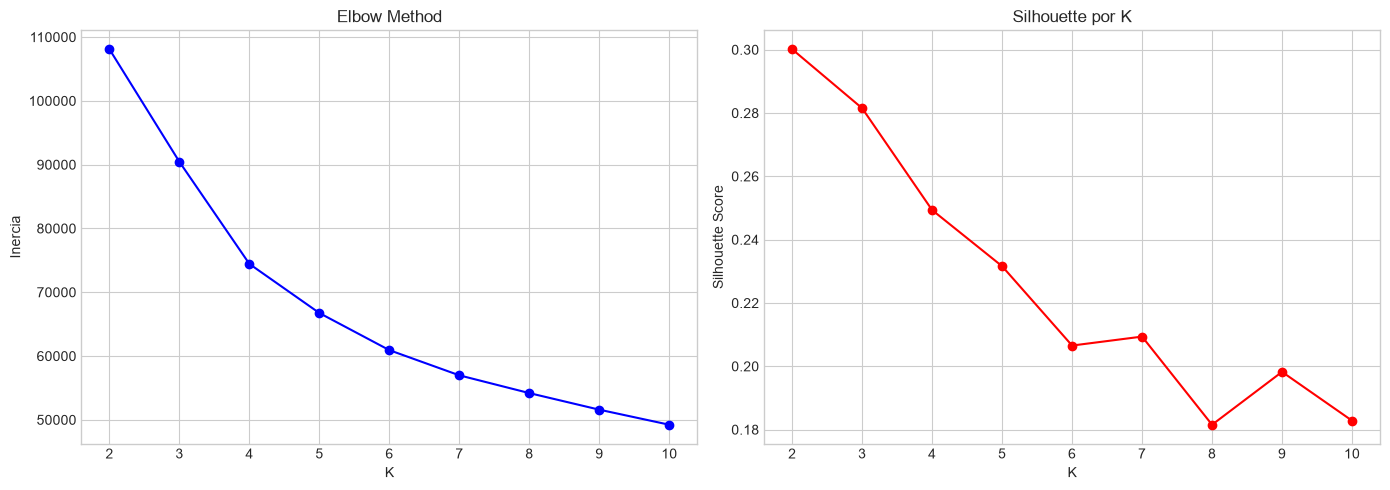

In [10]:
# 1 fila x 2 columnas de graficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva del codo: inercia vs K
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

# Curva de silhouette vs K
axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette por K')
axes[1].grid(True)

# Ajusta el espaciado entre subplots
plt.tight_layout()
# Muestra la figura
plt.show()

### Hallazgos

- La inercia se aplana a partir de **K=4** (74 434) y el silhouette cae de 0.300 (K=2) a 0.249 (K=4) antes de desplomarse.
- **Conviene K=4:** mejor equilibrio entre compactación intra-cluster y separación.


## Ajuste del K-Means definitivo y Perfil de cada Cluster

Elegir K por el balance entre el codo de inercia (donde la reducción por cluster
adicional deja de ser sustancial) y un silhouette score todavía sostenido.

Promedio de las features originales (sin log ni escalar) por cluster, para leer
los resultados en unidades reales. Se agrega la categoría más frecuente de cada
cluster para darle un perfil de negocio.

In [11]:
K_FINAL = 4

# KMeans definitivo
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)

# Asigna la etiqueta de cluster a cada producto
catalogo_log['cluster'] = kmeans.fit_predict(X_escalado)

print('Tamaños de cluster:')
print(catalogo_log['cluster'].value_counts().sort_index())

# Promedio de features originales
perfil = catalogo_log.groupby('cluster')[features].mean().round(2)

# Categoria mas frecuente de cada cluster
categoria_dominante = catalogo_log.groupby('cluster')['product_category_name_english'].agg(
    lambda x: x.value_counts().index[0] # func. rapida (x: categorias del cluster) y toma la moda
)

# Agrega la categoria dominante al perfil
perfil['categoria_dominante'] = categoria_dominante
perfil


Tamaños de cluster:
cluster
0    11068
1     4354
2     3751
3    13150
Name: count, dtype: int64


,precio_promedio,flete_promedio,veces_vendido,product_weight_g,volumen_cm3,categoria_dominante
cluster,,,,,,
0,47.34,14.04,1.73,345.14,3655.28,health_beauty
1,390.91,50.05,2.28,10014.62,61119.07,furniture_decor
2,89.11,17.20,16.21,1172.78,10161.27,bed_bath_table
3,163.68,18.91,1.61,1656.62,14535.92,bed_bath_table


## Ubicar los clusters en el espacio PCA

Graficar los clusters en el plano de las dos primeras componentes (PC1-PC2) y
en una proyección 3D (PC1-PC2-PC3) para comprobar visualmente qué tan
separados quedan los grupos.


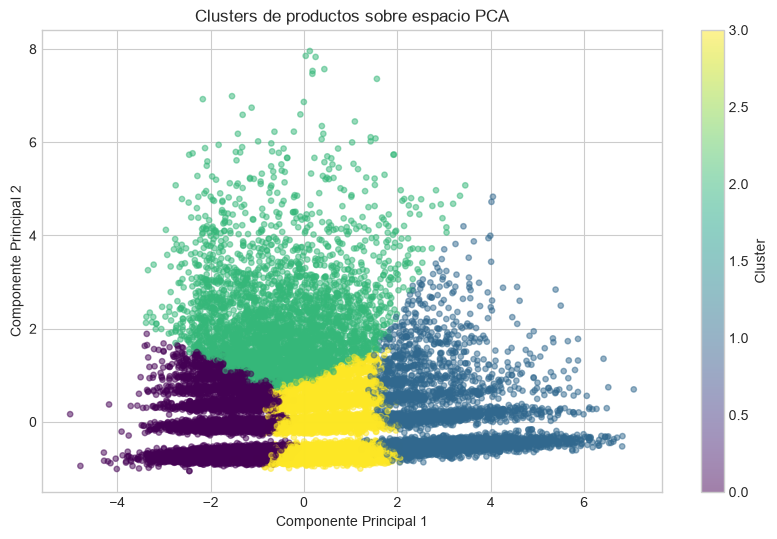

In [12]:
# Tamano de la figura
plt.figure(figsize=(10, 6))
# Scatter de la componente 1 vs componente 2
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
# Color por cluster
    c=catalogo_log['cluster'], cmap='viridis', alpha=0.5, s=15)
# Barra de color
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1') # tamanho fisico del producto
plt.ylabel('Componente Principal 2') # popularidad
plt.title('Clusters de productos sobre espacio PCA')
# Muestra el grafico
plt.show()

### Hallazgos

- **PC1 (52.7%) = Tamaño físico** (peso, volumen, flete, precio); **PC2 (20.1%) = Popularidad** ("veces vendido").
- El cluster de alta rotación queda aislado por PC2 y el de grandes/premium por PC1; los de bajo y medio movimiento se apilan en el centro.
- Con **K=4** los grupos se separan bien salvo los dos centrales, que solo se despegan en la 3D.


## Proyección 3D de los clusters

Como el PCA conserva 85.8% de la varianza con 3 componentes, también podemos
explorar la separación de los clusters en el espacio tridimensional.


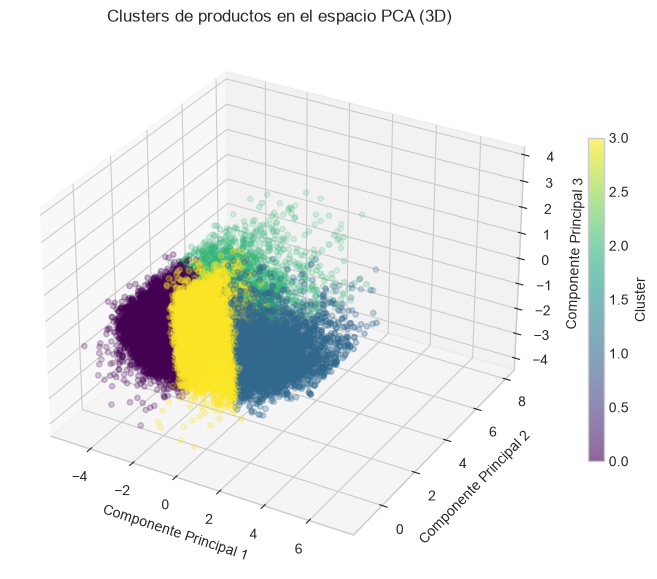

In [13]:
# Scatter 3D de las 3 componentes, color por cluster
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
s3d = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                 c=catalogo_log['cluster'], cmap='viridis', alpha=0.6, s=15)
ax.set_xlabel('Componente Principal 1') # tamanho del producto
ax.set_ylabel('Componente Principal 2') # popularidad
ax.set_zlabel('Componente Principal 3') # precio relativo
ax.set_title('Clusters de productos en el espacio PCA (3D)')
plt.colorbar(s3d, label='Cluster', shrink=0.6)
plt.show()


### Hallazgos

- **PC3 (13.1%) = Precio relativo** (precio 0.64, volumen 0.57); la varianza total sube a 85.8%.
- La tercera dimensión despega los clusters 0 y 3, solapados en 2D.
- **Configuración ganadora: K=4 con PCA 3D**, donde los 4 clusters quedan bien delimitados.


## Recomendador por cluster

Para un producto dado, se buscan primero productos de la **misma categoria** dentro de
su cluster (recomendacion coherente). Si no alcanzan, se completa con el resto del cluster
ordenado por cercania de precio.

In [14]:
# Recomendador semantico: misma categoria dentro del mismo cluster
def recomendar(product_id, n=5):
    # Ubica la fila del producto consultado
    fila = catalogo_log[catalogo_log['product_id'] == product_id]

    if fila.empty:
        return f'Producto {product_id} no encontrado'

    # Cluster y categoria del producto consultado
    cluster_id = fila['cluster'].iloc[0]
    categoria = fila['product_category_name_english'].iloc[0]

    # Candidatos preferidos: mismo cluster Y misma categoria (excluyendo al propio)
    candidatos = catalogo_log[
        (catalogo_log['cluster'] == cluster_id) &
        (catalogo_log['product_category_name_english'] == categoria) &
        (catalogo_log['product_id'] != product_id)
    ].copy()

    # Ordena por cercania de precio al producto consultado
    precio_ref = fila['precio_promedio'].iloc[0]
    candidatos['diff_precio'] = (candidatos['precio_promedio'] - precio_ref).abs()
    candidatos = candidatos.sort_values('diff_precio')

    # Si no alcanzan, completa con el resto del cluster (otras categorias)
    if len(candidatos) < n:
        resto = catalogo_log[
            (catalogo_log['cluster'] == cluster_id) &
            (catalogo_log['product_id'] != product_id)
        ].copy()
        resto = resto[~resto['product_id'].isin(candidatos['product_id'])]
        resto['diff_precio'] = (resto['precio_promedio'] - precio_ref).abs()
        resto = resto.sort_values('diff_precio')
        candidatos = pd.concat([candidatos, resto], ignore_index=True)

    # Devuelve las columnas utiles para recomendar
    return candidatos[['product_id', 'product_category_name_english', 'precio_promedio']].head(n)

primer_producto = catalogo_log[['product_id', 'product_category_name_english', 'precio_promedio' ]].iloc[0]
print(f'Recomendaciones para producto: {primer_producto}')
# Genera las recomendaciones
recomendar(primer_producto['product_id'])

Recomendaciones para producto: product_id                       00066f42aeeb9f3007548bb9d3f33c38
product_category_name_english                           perfumery
precio_promedio                                            101.65
Name: 0, dtype: object


,product_id,product_category_name_english,precio_promedio
20752,a1766f2d27b4e90a0d78d8e115295399,perfumery,102.48
12143,5daa4a09c9afb3b30d6df995fab5c2dc,perfumery,100.00
2516,132893fa155be7225b6ecf7d4fe3ce9a,perfumery,100.00
83,00c3e35b00dd00ab864d4a94c1b97e66,perfumery,99.99
26464,cd7701670288642f7be9437dec9034c1,perfumery,99.99


## Conclusiones

- **El catálogo se organiza en 4 segmentos** (K=4, silhouette 0.249): un 40% es long-tail de bajo
  movimiento; el resto reparte best sellers, productos grandes/premium y chicos económicos.
- **Los ejes que separan el catálogo son claros:** tamaño físico (PC1, 52.7%), popularidad (PC2,
  20.1%) y precio relativo (PC3, 13.1%).
- **K=4 con PCA 3D es la configuración a usar:** los 4 clusters quedan bien delimitados y explican
  el 85.8% de la varianza.
- **Para Olist:** operar por segmento — stock y despacho inmediato para los best sellers, y fletes
  dedicados para los productos voluminosos, donde el costo de envío golpea la conversión.
